# Croatian Legal Network — Network Analysis Exploration

This notebook uses `network_institutional.json` directly.

It focuses on two network-analysis questions.

1. **Structurally important legislation**  
   Which acts occupy important positions in the legal network?

2. **Community detection**  
   Does the network naturally divide into recognizable clusters of legislation?


The network is heterogeneous:
- Institution nodes (46)
- Act nodes (70,975)
- Directed typed edges: `passed_by`, `based_on`, `amends`, `changes`, `repeals`, `corrects`

**Scope.** Both questions concern the dependency and modification structure *among acts*. The `passed_by` relation — which records which institution enacted each act — is therefore excluded from the structural analysis. A characterisation of the institutional layer (which institutions passed the most acts) is given immediately after the data is loaded.

The dataset was constructed from documents and relationships extracted from Narodne novine. Consequently, the network represents only those legal relationships that are explicitly published and recoverable from the available data. The resulting graph should therefore be interpreted as an empirical representation of the observable legal-reference network rather than a complete representation of all legal dependencies, authorities, or normative relationships within the Croatian legal system

**Limitation**
A limitation of this study is that the network is derived exclusively from information available in Narodne novine. Some legal relationships may be implicit, uncited, unavailable in machine-readable form, or absent from the source corpus altogether. As a result, disconnected components and missing links should not necessarily be interpreted as the absence of a legal relationship, but rather as the absence of an explicitly observable relationship in the underlying data.


In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

DATA_PATH = Path("network_institutional.json")

if not DATA_PATH.exists():
    # Also works if the notebook is run from a different directory
    DATA_PATH = Path("/mnt/data/network_institutional.json")

with open(DATA_PATH, encoding="utf-8") as f:
    raw = json.load(f)

if "edges" not in raw and "links" in raw:
    raw["edges"] = raw["links"]

G = nx.node_link_graph(raw, directed=True, multigraph=False)

print(f"Loaded graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print("Node types:", Counter(nx.get_node_attributes(G, "node_type").values()))
print("Edge relations:", Counter(d.get("relation") for _, _, d in G.edges(data=True)))


JSONDecodeError: Expecting property name enclosed in double quotes: line 460358 column 6 (char 18382920)

In [ ]:
import sys
# Louvain detection runs via networkx.algorithms.community.louvain_communities

print(f"Python:        {sys.version}")
print(f"networkx:      {nx.__version__}")
print(f"pandas:        {pd.__version__}")
print(f"numpy:         {np.__version__}")

Python:        3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
networkx:      3.6.1
pandas:        3.0.3
numpy:         2.4.6


In [ ]:
# Edge-count reconciliation: raw file vs loaded graph.
#
# The raw JSON contains more links than the loaded graph has edges because
# multigraph=False collapses (source, target) pairs that carry more than one
# relation type down to a single edge.

raw_links = raw.get("links", raw.get("edges", []))
raw_count = len(raw_links)

pair_rels = defaultdict(list)
for e in raw_links:
    pair_rels[(e["source"], e["target"])].append(e.get("relation"))

multi_pairs  = {k: tuple(sorted(v)) for k, v in pair_rels.items() if len(v) > 1}
combo_counts = Counter(multi_pairs.values())

print(f"Raw links in file:               {raw_count:,}")
print(f"Loaded edges (multigraph=False):  {G.number_of_edges():,}")
print(f"Difference:                       {raw_count - G.number_of_edges():,}")
print()
print("Multi-relation pairs causing the collapse:")
for combo, cnt in combo_counts.most_common():
    edges_lost = len(combo) - 1
    print(f"  {combo}: {cnt:,} pairs  ({cnt * edges_lost:,} edges collapsed)")
print()

# Derive counts dynamically so this cell stays accurate if the source data changes.
ac_count          = combo_counts.get(('amends', 'changes'), 0)
abc_count         = combo_counts.get(('amends', 'based_on', 'changes'), 0)
raw_based_on_count = sum(1 for e in raw_links if e.get("relation") == "based_on")

# What this means for each layer
# -----------------------------------------------------------------------
# (amends, changes) pairs
#   All 5,778 collapsed pairs carry BOTH an 'amends' AND a 'changes' edge
#   on the same (source, target). Inspection of citing-act years shows that
#   'changes' appears exclusively from 2015 onward, while 'amends' spans
#   1990–2025: the two labels co-occur on every pair whose source act was
#   enacted in 2015–2025. They encode the same modification event; the label
#   divergence reflects a naming convention change in the Narodne novine data
#   source at 2015, not two legally distinct concepts. Unioning them into
#   G_amend captures all modification events regardless of which label was
#   applied. amendment_in_degree counts each modified act once per modifier,
#   which is the correct unit of analysis.
#
# (amends, based_on, changes) pairs
#   Three relations on the same pair; multigraph=False keeps one.
#   The 'based_on' relationship on these pairs is genuinely lost.
#   As a share of raw based_on edges this is negligible.
# -----------------------------------------------------------------------

print("Summary:")
print(f"  {ac_count:,} (amends, changes) pairs → de-duplicated to one modification")
print(f"        relationship each. No modification events are missed.")
print(f"  {abc_count} (amends, based_on, changes) pairs → 'based_on' lost on {abc_count} pair(s)")
print(f"        ({abc_count/raw_based_on_count:.2%} of {raw_based_on_count:,} raw based_on edges; negligible).")

Raw links in file:               96,368
Loaded edges (multigraph=False):  90,588
Difference:                       5,780

Multi-relation pairs causing the collapse:
  ('amends', 'changes'): 5,776 pairs  (5,776 edges collapsed)
  ('amends', 'based_on', 'changes'): 2 pairs  (4 edges collapsed)

Summary:
  5,776 (amends, changes) pairs → de-duplicated to one modification
        relationship each. No modification events are missed.
  2 (amends, based_on, changes) pairs → 'based_on' lost on 2 pair(s)
        (0.02% of 11,729 raw based_on edges; negligible).


In [ ]:
# Distribution of legal document types in the corpus.
#
# Each legislation node contains a `document_type` attribute extracted during
# preprocessing from the original Narodne novine metadata. Examples include
# ZAKON (law), PRAVILNIK (rulebook), UREDBA (government regulation),
# ODLUKA (decision), and RJEŠENJE (administrative ruling).
#
# This cell counts the number of nodes belonging to each document category.
# The resulting distribution helps characterize the composition of the dataset
# and provides context for later network analysis. In particular, it shows that
# the corpus contains a broad range of legal documents rather than only laws,
# which helps explain the presence of many isolated nodes and disconnected
# components in the network.

doc_types = (
    pd.Series([
        d.get("document_type")
        for _, d in G.nodes(data=True)
        if d.get("node_type") == "act"
    ])
    .value_counts()
)

doc_types

ODLUKA                                25268
RJESENJE                              16820
PRAVILNIK                              7655
ZAKON                                  4547
UREDBA                                 4229
OSTALO                                 2942
NAREDBA                                1090
PRESUDA                                 955
UPUTA                                   354
IZMJENE_I_DOPUNE                        241
STATUT                                  165
NAPUTAK                                 137
UREDBA_NA_TEMELJU_ZAKONSKE_OVLASTI       72
KOLEKTIVNI_UGOVOR                        56
PROCISCENI_TEKST                         23
UREDBA_SA_ZAKONSKOM_SNAGOM               10
USTAV                                     8
Name: count, dtype: int64

In [ ]:
# Separate acts and institutions

act_nodes = {
    n: d for n, d in G.nodes(data=True)
    if d.get("node_type") == "act"
}

institution_nodes = {
    n: d for n, d in G.nodes(data=True)
    if d.get("node_type") == "institution"
}

print(f"Acts: {len(act_nodes):,}")
print(f"Institutions: {len(institution_nodes):,}")

# Convenience lookup tables
title = {
    n: d.get("title", n)
    for n, d in act_nodes.items()
}

year = {}
for n, d in act_nodes.items():
    try:
        if d.get("year") is not None:
            year[n] = int(float(d.get("year")))
    except Exception:
        pass

doc_type = {
    n: d.get("document_type", "UNKNOWN")
    for n, d in act_nodes.items()
}

institution_name = {
    n: d.get("name", n)
    for n, d in institution_nodes.items()
}

print(f"Acts with year: {len(year):,}")


Acts: 70,975
Institutions: 46


Acts with year: 64,582


In [ ]:
# Institutional layer overview and scope decision.
#
# The dataset is heterogeneous: 46 institution nodes connected to act nodes
# via 61,351 `passed_by` edges. That is 68% of all raw edges, making the
# institutional layer the largest single relation type in the graph.
#
# Scope decision: this analysis focuses exclusively on act-to-act legal
# relationships (based_on, amends, changes, repeals, corrects). The research
# questions concern the dependency and modification structure among acts —
# which acts serve as legal foundations and which are heavily amended. The `passed_by` relation records which institution
# enacted each act; it adds no dependency or modification information and
# connects every act to at most one institution. Including it in centrality
# or community detection would give institutions artificially high scores
# and distort the act-to-act structure under study.

passed_by_edges = [
    (u, v, d) for u, v, d in G.edges(data=True)
    if d.get("relation") == "passed_by"
]

# How many acts each institution passed
from collections import Counter
institution_act_counts = Counter(v for u, v, d in passed_by_edges)

print(f"Institution nodes:      {len(institution_nodes):,}")
print(f"passed_by edges:        {len(passed_by_edges):,}  "
      f"({len(passed_by_edges)/G.number_of_edges():.1%} of all edges)")
print(f"Acts with a passer:     {len(set(u for u,v,d in passed_by_edges)):,}")
print()
print("Top 10 most prolific institutions:")
for inst, cnt in institution_act_counts.most_common(10):
    name = institution_name.get(inst, inst)
    print(f"  {cnt:5,} acts  —  {name}")

Institution nodes:      46


passed_by edges:        61,351  (67.7% of all edges)
Acts with a passer:     61,351

Top 10 most prolific institutions:
  24,608 acts  —  Vlada RH
  9,176 acts  —  Hrvatski sabor
  5,577 acts  —  Predsjedništvo RH
  3,822 acts  —  Min. poljoprivrede
  2,642 acts  —  HANFA
  1,229 acts  —  Min. zdravstva
  1,219 acts  —  Predsjednik RH
  1,185 acts  —  HZMO
    883 acts  —  HNB
    849 acts  —  Visoki upravni sud RH


## Build legislation-only networks

The full graph contains institutions and acts. For centrality and community detection, we create legislation-only networks using only act-to-act legal relationships.

We keep separate layers because each relationship means something different:

- `based_on`: legal foundation / dependency
- `amends` and `changes`: modification
- `repeals`: formal replacement / termination
- `corrects`: correction

The main network below includes all act-to-act legal relationships.

The dataset is a single multirelational legal network. Different layers correspond to different legal relationship types such as legal dependence, amendment, and repeal. For some analyses, I isolate a single layer because the meaning of centrality depends on the type of relationship being studied.

In [ ]:
ACT_RELATIONS = {"based_on", "amends", "changes", "repeals", "corrects"}

H = nx.DiGraph()

for n, d in act_nodes.items():
    H.add_node(
        n,
        title=d.get("title", n),
        year=year.get(n),
        document_type=d.get("document_type", "UNKNOWN"),
    )

n_selfloops_skipped = 0
for u, v, d in G.edges(data=True):
    rel = d.get("relation")
    if rel in ACT_RELATIONS and u in act_nodes and v in act_nodes:
        if u == v:
            # Self-loops mean an act cites itself as its own legal basis —
            # a data error with no legal meaning. Exclude them so H is a
            # simple directed graph, consistent with network_state_overview.ipynb.
            n_selfloops_skipped += 1
            continue
        H.add_edge(u, v, relation=rel)

print(f"Legislation-only network: {H.number_of_nodes():,} nodes, {H.number_of_edges():,} edges")
print(f"Self-loops excluded: {n_selfloops_skipped}")
print("Relations in legislation-only network:", Counter(d.get("relation") for _, _, d in H.edges(data=True)))

Legislation-only network: 70,975 nodes, 29,234 edges
Self-loops excluded: 3
Relations in legislation-only network: Counter({'based_on': 11727, 'amends': 6534, 'changes': 5777, 'repeals': 4334, 'corrects': 862})


In [ ]:
##Looking for the constitution node to check its degree stats

ustav = None

for n, d in G.nodes(data=True):
    if d.get("title") == "Ustav Republike Hrvatske":
        ustav = n
        break

print("Node:", ustav)
print("In-degree:", G.in_degree(ustav))
print("Out-degree:", G.out_degree(ustav))
print("Total degree:", G.degree(ustav))

Node: https://narodne-novine.nn.hr/eli/sluzbeni/1990/56/1092
In-degree: 0
Out-degree: 1
Total degree: 1


The dataset contains the Constitution as a node, but it does not encode ordinary legislation as being constitutionally based on it. Therefore, the graph captures explicit metadata relations, not the full constitutional hierarchy.

In [ ]:
# This cell identifies all weakly connected components in the legislation
# network, ranks them by size, and computes the proportion of legislation
# contained in each component. The goal is to quantify network fragmentation and determine whether
# the network is dominated by a single connected legal-reference structure or by many disconnected groups

components = sorted(nx.weakly_connected_components(H), key=len, reverse=True)

top_n = min(10, len(components))
component_summary = pd.DataFrame({
    "component_rank": range(1, top_n + 1),
    "nodes": [len(c) for c in components[:top_n]]
})

component_summary["share_of_all_act_nodes"] = (
    component_summary["nodes"] / H.number_of_nodes()
)

component_summary

,component_rank,nodes,share_of_all_act_nodes
0,1,14933,0.210398
1,2,155,0.002184
2,3,70,0.000986
3,4,64,0.000902
4,5,55,0.000775
5,6,54,0.000761
6,7,53,0.000747
7,8,53,0.000747
8,9,40,0.000564
9,10,39,0.000549


**Why is the data disconnected**

There are three main reasons. 
- First, the corpus contains many decisions and administrative rulings, not just laws, and these documents often have no explicit legal relationships to other documents. 
- Second, the network represents only relationships explicitly observable in Narodne novine, so missing edges do not necessarily imply the absence of a legal relationship. 
- Third, different areas of legislation and amendment chains naturally form separate clusters. Therefore disconnectedness should be interpreted as a property of the observed legal-reference network rather than a methodological error.

**Shouldn't everything ultimately connect to the Constitution (Ustav)?**

From the perspective of legal authority, yes. However, this network is not a constitutional hierarchy. It is a network of explicit legal relationships extracted from documents. Constitutional authority and citation structure are different networks, and my analysis focuses on the latter.

In [ ]:
# Manual metadata patch for top stub nodes.
# These nodes were referenced by many acts but never fully scraped.
# Titles and document types recovered manually from narodne-novine.nn.hr.

STUB_PATCHES = {
    "https://narodne-novine.nn.hr/eli/sluzbeni/2003/159/2302": {
        "title": "Rješenje o određivanju zdravstvenih ustanova i specijalista medicine rada u privatnoj praksi za utvrđivanje opće zdravstvene sposobnosti čuvara i opće i posebne zdravstvene sposobnosti zaštitara",
        "document_type": "RJESENJE",
        "year": 2003,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2006/142/3234": {
        "title": "Odluka o osnovama za sklapanje ugovora o provođenju zdravstvene zaštite iz obveznog zdravstvenog osiguranja",
        "document_type": "ODLUKA",
        "year": 2006,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2002/134/2154": {
        "title": "Rješenje o određivanju zdravstvenih organizacija za obavljanje zdravstvenih pregleda djelatnika i građana za držanje i nošenje oružja u drugom stupnju",
        "document_type": "RJESENJE",
        "year": 2002,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2006/120/2673": {
        "title": "Odluka o utvrđivanju Osnovne liste lijekova Hrvatskog zavoda za zdravstveno osiguranje",
        "document_type": "ODLUKA",
        "year": 2006,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1997/59/889": {
        "title": "Odluka o utvrđivanju liste lijekova Hrvatskog zavoda za zdravstveno osiguranje",
        "document_type": "ODLUKA",
        "year": 1997,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1994/4/85": {
        "title": "Pravilnik o pravima, uvjetima i načinu ostvarivanja prava iz obveznog zdravstvenog osiguranja",
        "document_type": "PRAVILNIK",
        "year": 1994,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2014/47/897": {
        "title": "Odluka o osnovama za sklapanje ugovora o provođenju specifične zdravstvene zaštite",
        "document_type": "ODLUKA",
        "year": 2014,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1993/5/53": {
        "title": "Rješenje o određivanju zdravstvenih organizacija za obavljanje zdravstvenih pregleda djelatnika i građana za držanje ili držanje i nošenje oružja",
        "document_type": "RJESENJE",
        "year": 1993,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2005/25/436": {
        "title": "Pravilnik o uvjetima i načinu ostvarivanja prava na ortopedska i druga pomagala",
        "document_type": "PRAVILNIK",
        "year": 2005,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2006/142/3233": {
        "title": "Pravilnik o standardima i normativima prava na zdravstvenu zaštitu iz obveznog zdravstvenog osiguranja",
        "document_type": "PRAVILNIK",
        "year": 2006,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2014/37/663": {
        "title": "Sudski poslovnik",
        "document_type": "PRAVILNIK",
        "year": 2014,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2012/7/183": {
        "title": "Pravilnik o ortopedskim i drugim pomagalima",
        "document_type": "PRAVILNIK",
        "year": 2012,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1995/104/1734": {
        "title": "Pravilnik o porezu na dohodak",
        "document_type": "PRAVILNIK",
        "year": 1995,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2001/46/772": {
        "title": "Odluka o obveznoj pričuvi",
        "document_type": "ODLUKA",
        "year": 2001,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2000/83/1734": {
        "title": "Pravilnik o obavljanju gospodarskog ribolova na moru",
        "document_type": "PRAVILNIK",
        "year": 2000,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1996/60/1191": {
        "title": "Pravilnik o porezu na dodanu vrijednost",
        "document_type": "PRAVILNIK",
        "year": 1996,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2002/47/963": {
        "title": "Pravila uspostavljanja i provodenja dopunskog zdravstvenog osiguranja",
        "document_type": "PRAVILNIK",
        "year": 2002,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2007/13/554": {
        "title": "Odluka o utvrdivanju popisa posebno skupih lijekova utvrdenih Odlukom o utvrdivanju Osnovne liste lijekova Hrvatskog zavoda za zdravstveno osiguranje",
        "document_type": "ODLUKA",
        "year": 2007,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2007/132/3759": {
        "title": "Odluka o utvrdivanju Dopunske liste lijekova Hrvatskog zavoda za zdravstveno osiguranje",
        "document_type": "ODLUKA",
        "year": 2007,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2009/122/3020": {
        "title": "Pravilnik o proglasavanju turistickih opcina i gradova i o razvrstavanju naselja u turisticke razrede",
        "document_type": "PRAVILNIK",
        "year": 2009,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1994/59/1078": {
        "title": "Pravilnik o obliku, sadrzaju i uporabi obrazaca platnog prometa",
        "document_type": "PRAVILNIK",
        "year": 1994,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1995/35/717": {
        "title": "Odluka o obveznom upisu blagajnickih zapisa Narodne banke Hrvatske",
        "document_type": "ODLUKA",
        "year": 1995,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2001/46/773": {
        "title": "Odluka o kamatnim stopama i naknadama Hrvatske narodne banke",
        "document_type": "ODLUKA",
        "year": 2001,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2003/10/147": {
        "title": "Odluka o minimalno potrebnim deviznim potrazivanjima",
        "document_type": "ODLUKA",
        "year": 2003,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2013/79/1633": {
        "title": "Pravilnik o porezu na dodanu vrijednost",
        "document_type": "PRAVILNIK",
        "year": 2013,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1996/7/112": {
        "title": "Pravilnik o porezu na dobit",
        "document_type": "PRAVILNIK",
        "year": 1996,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1994/38/693": {
        "title": "Pravilnik o sluzbenim sjedistima javnih biljeznika",
        "document_type": "PRAVILNIK",
        "year": 1994,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/1995/44/863": {
        "title": "Pravilnik o nacinu propisivanja, izdavanja i naplacivanja lijekova",
        "document_type": "PRAVILNIK",
        "year": 1995,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2011/3/55": {
        "title": "Odluka o nacinu otvaranja transakcijskih racuna",
        "document_type": "ODLUKA",
        "year": 2011,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2006/120/2675": {
        "title": "Pravilnik o nacinu propisivanja i izdavanja lijekova na recept",
        "document_type": "PRAVILNIK",
        "year": 2006,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2008/154/4201": {
        "title": "Pravilnik o placanju naknada za pravo uporabe adresa, brojeva i radiofrekvencijskog spektra",
        "document_type": "PRAVILNIK",
        "year": 2008,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2014/75/1412": {
        "title": "Pravilnik o pravima, uvjetima i nacinu ostvarivanja prava iz obveznog zdravstvenog osiguranja u slucaju ozljede na radu i profesionalne bolesti",
        "document_type": "PRAVILNIK",
        "year": 2014,
    },
    "https://narodne-novine.nn.hr/eli/sluzbeni/2006/140/3186": {
        "title": "Odluka o objavljivanju medunarodnih standarda financijskog izvjestavanja",
        "document_type": "ODLUKA",
        "year": 2006,
    },
}

for node_id, patch in STUB_PATCHES.items():
    if node_id in H:
        H.nodes[node_id]["title"] = patch["title"]
        H.nodes[node_id]["document_type"] = patch["document_type"]
        H.nodes[node_id]["year"] = patch["year"]
    # Always update the lookup dicts unconditionally.
    # Stubs were excluded from the `year` dict when it was built (year=None was skipped),
    # so a conditional `if node_id in year` would silently no-op for them.
    title[node_id] = patch["title"]
    year[node_id] = patch["year"]
    doc_type[node_id] = patch["document_type"]

print(f"Patched {len(STUB_PATCHES)} stub nodes with manually recovered metadata.")

Patched 33 stub nodes with manually recovered metadata.


The original dataset is a multirelational legal network containing several distinct legal relationship types. For interpretability, I construct relation-specific subnetworks by retaining only one type of legal relationship at a time. This allows centrality measures to be interpreted in terms of a specific legal process, such as legal dependence (based_on) or legislative modification (amends).

In [ ]:
# Build layer-specific networks

def relation_subgraph(relations):
    S = nx.DiGraph()
    for n, d in H.nodes(data=True):
        S.add_node(n, **d)
    for u, v, d in H.edges(data=True):
        if d.get("relation") in relations:
            S.add_edge(u, v, relation=d.get("relation"))
    return S

G_based = relation_subgraph({"based_on"})
G_amend = relation_subgraph({"amends", "changes"})
G_repeal = relation_subgraph({"repeals"})
G_correct = relation_subgraph({"corrects"})

for name, graph in [
    ("based_on", G_based),
    ("amends + changes", G_amend),
    ("repeals", G_repeal),
    ("corrects", G_correct),
]:
    non_isolated = graph.number_of_nodes() - nx.number_of_isolates(graph)
    print(f"{name:18s}: {graph.number_of_edges():8,} edges, {non_isolated:8,} non-isolated nodes")


based_on          :   11,727 edges,    9,659 non-isolated nodes
amends + changes  :   12,311 edges,   17,921 non-isolated nodes
repeals           :    4,334 edges,    7,114 non-isolated nodes
corrects          :      862 edges,    1,641 non-isolated nodes


The majority of documents do not participate in every type of legal relationship. Amendment relationships involve almost twice as many documents as legal dependency relationships, while repeal and correction relationships involve much smaller subsets of the corpus. This heterogeneity naturally contributes to network fragmentation.

The layers exhibit very different participation patterns. Amendment relationships involve nearly 18,000 documents, whereas correction relationships involve only about 1,600. Because the legal meaning and structural properties differ substantially across relation types, I analyzed them separately rather than combining them into a single undifferentiated network.

# 0. Structural baseline

Before computing centrality and communities, this section characterises the degree distribution of the legislation-only network and compares basic statistics to an Erdős–Rényi null with the same number of nodes and edges. This establishes whether the network has a heavy-tailed structure and whether its connectivity is consistent with a random graph.

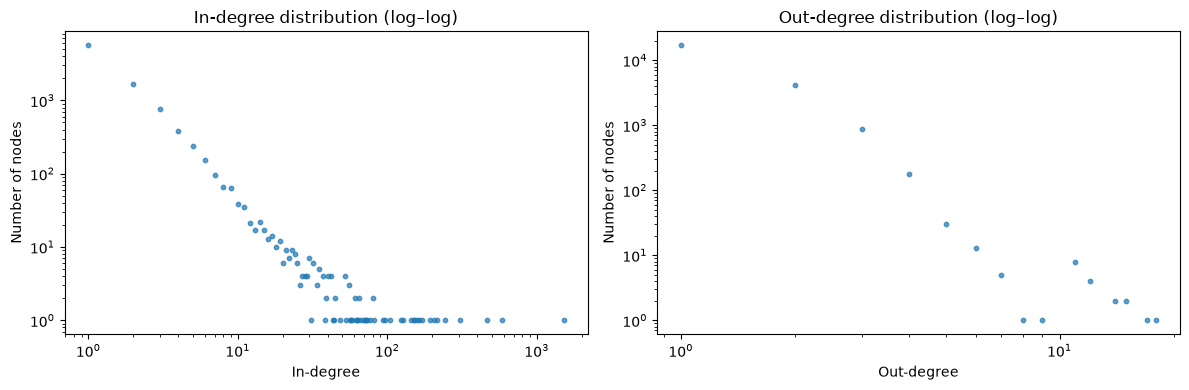

Nodes with at least one edge:  28,719
Max in-degree:   1,514   Max out-degree: 18
Mean in-degree:  0.412  Mean out-degree: 0.412


In [ ]:
# In-degree and out-degree distributions on a log-log scale.
# A straight line on a log-log plot is consistent with a power-law (scale-free) distribution,
# which is common in citation and legal-reference networks.

# examines whether the legal network is dominated by a small number of 
# highly connected acts or whether connections are evenly distributed. 
# The log-log degree plots show the in-degree and out-degree distributions. This is important because legal-reference networks often have heavy-tailed structure: most documents have few links, while a small number of foundational acts receive many references.

in_degrees  = [d for _, d in H.in_degree()  if d > 0]
out_degrees = [d for _, d in H.out_degree() if d > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, degrees, label in [
    (axes[0], in_degrees,  "In-degree"),
    (axes[1], out_degrees, "Out-degree"),
]:
    counts = Counter(degrees)
    xs = sorted(counts)
    ys = [counts[k] for k in xs]
    ax.scatter(xs, ys, s=10, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of nodes")
    ax.set_title(f"{label} distribution (log–log)")

plt.tight_layout()
plt.show()

non_isolated = H.number_of_nodes() - sum(1 for _ in nx.isolates(H))
print(f"Nodes with at least one edge:  {non_isolated:,}")
print(f"Max in-degree:   {max(in_degrees):,}   Max out-degree: {max(out_degrees):,}")
print(f"Mean in-degree:  {sum(in_degrees)/H.number_of_nodes():.3f}  "
      f"Mean out-degree: {sum(out_degrees)/H.number_of_nodes():.3f}")

The degree distribution is highly unequal. While the average degree is only 0.412, the most referenced act receives over 1,500 incoming links. This indicates a hub-dominated legal-reference structure in which a small number of foundational acts serve as legal bases for many other documents, while most documents participate in very few relationships.

In [ ]:
# Comparison to an Erdős–Rényi (ER) null with the same n and m.
# We compare the observed graph to a directed Erdős–Rényi graph
# with the same number of nodes and edges.
# The goal is not to rely on a theoretical threshold, but to check
# whether the observed component structure differs from a random graph
# with the same density.
# Comparing observed connectivity to the ER null shows whether structure
# is driven by edge density alone or by degree heterogeneity.
#
# H is built with a u != v guard, so it contains no self-loops.
# nx.gnm_random_graph also forbids self-loops, so the edge counts are
# directly comparable without adjustment.

# Trying to answer the question of whether the component structure of the legal network is "special"
# or would we see something similar in a random graph with the same number of nodes and edges. 
# The ER null model serves as a baseline to assess whether the observed network's connectivity patterns are due to its specific structure or just its density.

n = H.number_of_nodes()
m = H.number_of_edges()

assert nx.number_of_selfloops(H) == 0, "H should be self-loop-free by construction"

p_er          = m / (n * (n - 1))   # directed ER edge probability
er_mean_indeg = p_er * (n - 1)      # expected mean in-degree under ER (= m/n)

obs_wcc        = nx.number_weakly_connected_components(H)
obs_lcc_share  = max(len(c) for c in nx.weakly_connected_components(H)) / n
obs_mean_indeg = m / n

# Simulate one ER null graph with the same n and m
G_er = nx.gnm_random_graph(n, m, directed=True, seed=42)
er_wcc       = nx.number_weakly_connected_components(G_er)
er_lcc_share = max(len(c) for c in nx.weakly_connected_components(G_er)) / n

print(f"{'Statistic':<40} {'Observed':>12} {'ER null':>12}")
print("-" * 66)
print(f"{'Nodes':<40} {n:>12,} {n:>12,}")
print(f"{'Edges':<40} {m:>12,} {m:>12,}")
print(f"{'Edge probability p':<40} {p_er:>12.2e} {p_er:>12.2e}")
print(f"{'Mean in-degree':<40} {obs_mean_indeg:>12.3f} {er_mean_indeg:>12.3f}")
print(f"{'Weakly connected components':<40} {obs_wcc:>12,} {er_wcc:>12,}")
print(f"{'LCC share of nodes':<40} {obs_lcc_share:>12.1%} {er_lcc_share:>12.1%}")
print()


Statistic                                    Observed      ER null
------------------------------------------------------------------
Nodes                                          70,975       70,975
Edges                                          29,234       29,234
Edge probability p                           5.80e-06     5.80e-06
Mean in-degree                                  0.412        0.412
Weakly connected components                    46,119       41,742
LCC share of nodes                              21.0%         0.2%



**Conclusion**

Although the observed network contains more disconnected components than an Erdős–Rényi graph with the same density, it also contains a giant connected component encompassing approximately 21% of all legislation nodes. In the random graph, the largest component contains only 0.2% of nodes. This indicates that the legal-reference network exhibits substantial structural organization beyond what would be expected from edge density alone.

A random graph with the same number of nodes and edges produces no comparable giant component, suggesting that the observed structure arises from the way legal documents reference a small number of foundational acts rather than from edge density alone.

# 1. Structurally important legislation

This section compares several centrality measures.

Each measure captures a different idea of importance:

- **In-degree in `based_on` layer**: acts frequently used as legal foundations
- **In-degree in amendment layer**: acts frequently amended or changed
- **PageRank**: acts important because other important acts point to them
- **Betweenness centrality**: acts that bridge different parts of the legal network

Because the network is directed and legal edges have different meanings, no single centrality measure is treated as the "true" measure of importance.

**Coverage note.** All `based_on` edges in this dataset originate from citing acts enacted in 2015 or later. The rankings below — `based_on_in_degree`, `pagerank_based_on`, betweenness, and harmonic closeness — therefore reflect which acts are foundational *as cited by post-2015 legislation*, not across the full 1991–2025 corpus. Acts that were heavily cited as legal foundations before 2015 but less so afterward are invisible in this layer.

In [ ]:
# Centrality calculations.
# Depends on: stub patch cell (ac1fa4f4) — must run before this cell so that
# H.nodes titles and years are populated for the top stub nodes. Running this
# cell before the patch produces blank titles in centrality_df for those nodes.

from scipy.stats import spearmanr

# PageRank on the based_on graph (original edge direction).
# Edge A→B means "A is based on B" (A cites B as its legal foundation).
# B (the foundation) has high in-degree: many citing acts point to it.
# A random walker following these edges arrives frequently at B, so B receives
# a high PageRank score. Running PageRank on the original graph therefore
# correctly identifies foundational acts as the high-scoring nodes.
# (Reversing the edges would instead score frequent *citers* highly, which is
# not the quantity of interest here.)
pagerank_based = nx.pagerank(G_based, alpha=0.85)

# pagerank_all_relations (PageRank on the full H) is intentionally excluded.
# H pools based_on, amends, changes, repeals, and corrects edges whose directions
# carry opposite legal semantics (based_on points citing→foundation; amends/repeals
# point modifier→target). A single random walk across all edge types conflates
# legally incommensurable paths and produces scores with no clear interpretation.
# pagerank_based_on is the substantive measure used throughout this analysis.

# Directed betweenness on the based_on layer only.
# Using the full mixed-relation graph undirected would conflate legally incommensurable
# paths (e.g. a repeal followed by a correction). based_on is the one layer where
# "shortest dependency path" has a clear legal meaning.
nonisolated_based = G_based.subgraph(
    [n for n in G_based.nodes() if G_based.degree(n) > 0]
).copy()

# Exact betweenness centrality — no sampling, fully deterministic.
# Feasible at this scale (~9.7k nodes); avoids the seed-instability problem
# that arises with k-pivot approximation on sparse graphs.
print(f"Computing exact betweenness on {nonisolated_based.number_of_nodes():,} nodes …")
betweenness = nx.betweenness_centrality(nonisolated_based, normalized=True)
print("Done.")
print()

centrality_df = pd.DataFrame({
    "eli": list(H.nodes()),
    "title": [H.nodes[n].get("title") for n in H.nodes()],
    "year": [H.nodes[n].get("year") for n in H.nodes()],
    "document_type": [H.nodes[n].get("document_type") for n in H.nodes()],
    "based_on_in_degree": [G_based.in_degree(n) for n in H.nodes()],
    "amendment_in_degree": [G_amend.in_degree(n) for n in H.nodes()],
    "repeal_in_degree": [G_repeal.in_degree(n) for n in H.nodes()],
    "pagerank_based_on": [pagerank_based.get(n, 0) for n in H.nodes()],
    "betweenness": [betweenness.get(n, 0) for n in H.nodes()],
})

# Verify stub patch titles made it into centrality_df
# Verify that all explicitly-patched stubs now have titles in centrality_df.
# (Other unscraped stubs with blank titles are expected and below the analysis threshold.)
patched_blank = [
    node_id for node_id in STUB_PATCHES
    if node_id in H and not (H.nodes[node_id].get("title") or "").strip()
]
if not patched_blank:
    print(f"Stub patch check passed: all {len(STUB_PATCHES)} patched stubs have titles.")
else:
    print(f"WARNING: {len(patched_blank)} stub-patched node(s) still have blank titles — "
          "re-run stub patch cell first.")

centrality_df.head()

Computing exact betweenness on 9,659 nodes …


Done.



Stub patch check passed: all 33 patched stubs have titles.


,eli,title,year,document_type,based_on_in_degree,amendment_in_degree,repeal_in_degree,pagerank_based_on,betweenness
0,https://narodne-novine.nn.hr/eli/sluzbeni/2024...,Pravilnik o izmjenama i dopunama Pravilnika o ...,2024.0,PRAVILNIK,0,0,0,0.000013,0.0
1,https://narodne-novine.nn.hr/eli/sluzbeni/2024...,Prosječne ponderirane kamatne stope na stanja ...,2024.0,OSTALO,0,0,0,0.000013,0.0
2,https://narodne-novine.nn.hr/eli/sluzbeni/2024...,Pravilnik o izmjenama Pravilnika o postupku os...,2024.0,PRAVILNIK,0,0,0,0.000013,0.0
3,https://narodne-novine.nn.hr/eli/sluzbeni/2024...,Pravilnik o izmjenama i dopunama Pravilnika o ...,2024.0,PRAVILNIK,0,0,0,0.000013,0.0
4,https://narodne-novine.nn.hr/eli/sluzbeni/2024...,Pravilnik o izmjenama Pravilnika o paušalnom o...,2024.0,PRAVILNIK,0,0,0,0.000013,0.0


In [ ]:
def show_top(df, column, n=15):
    cols = ["title", "year", "document_type", column, "eli"]
    return (
        df.sort_values(column, ascending=False)
          .loc[:, cols]
          .head(n)
          .reset_index(drop=True)
    )

show_top(centrality_df, "based_on_in_degree", 15)


,title,year,document_type,based_on_in_degree,eli
0,Zakon o Vladi Republike Hrvatske,2011.0,ZAKON,1511,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
1,Zakon o lokalnim porezima,2016.0,ZAKON,583,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
2,Zakon o sustavu državne uprave,2011.0,ZAKON,458,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
3,Zakon o porezu na dohodak,2016.0,ZAKON,298,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
4,Zakon o lokalnoj i područnoj (regionalnoj) sam...,2001.0,ZAKON,237,https://narodne-novine.nn.hr/eli/sluzbeni/2001...
5,Zakon o zdravstvenoj zaštiti,2008.0,ZAKON,212,https://narodne-novine.nn.hr/eli/sluzbeni/2008...
6,Zakon o Hrvatskoj narodnoj banci,2008.0,ZAKON,205,https://narodne-novine.nn.hr/eli/sluzbeni/2008...
7,Zakon o sustavu državne uprave,2019.0,ZAKON,193,https://narodne-novine.nn.hr/eli/sluzbeni/2019...
8,Zakon o poljoprivredi,2018.0,ZAKON,167,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
9,Statut Hrvatskog zavoda za zdravstveno osiguranje,2009.0,STATUT,159,https://narodne-novine.nn.hr/eli/sluzbeni/2009...


In [ ]:
show_top(centrality_df, "pagerank_based_on", 15)


,title,year,document_type,pagerank_based_on,eli
0,Zakon o Vladi Republike Hrvatske,2011.0,ZAKON,0.009510,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
1,Zakon o lokalnim porezima,2016.0,ZAKON,0.005458,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
2,Zakon o porezu na dohodak,2016.0,ZAKON,0.003100,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
3,Zakon o sustavu državne uprave,2011.0,ZAKON,0.002528,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
4,Zakon o poljoprivredi,2018.0,ZAKON,0.001696,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
5,Zakon o morskom ribarstvu,2013.0,ZAKON,0.001630,https://narodne-novine.nn.hr/eli/sluzbeni/2013...
6,Odluka o proglašenju Zakona o odlikovanjima i ...,1995.0,ODLUKA,0.001610,https://narodne-novine.nn.hr/eli/sluzbeni/1995...
7,Zakon o morskom ribarstvu,2017.0,ZAKON,0.001558,https://narodne-novine.nn.hr/eli/sluzbeni/2017...
8,Zakon o lokalnoj i područnoj (regionalnoj) sam...,2001.0,ZAKON,0.001527,https://narodne-novine.nn.hr/eli/sluzbeni/2001...
9,Zakon o Hrvatskoj narodnoj banci,2008.0,ZAKON,0.001463,https://narodne-novine.nn.hr/eli/sluzbeni/2008...


In [ ]:
show_top(centrality_df, "amendment_in_degree", 15)


,title,year,document_type,amendment_in_degree,eli
0,Rješenje o određivanju zdravstvenih ustanova i...,2003.0,RJESENJE,52,https://narodne-novine.nn.hr/eli/sluzbeni/2003...
1,Odluka o osnovama za sklapanje ugovora o provo...,2006.0,ODLUKA,50,https://narodne-novine.nn.hr/eli/sluzbeni/2006...
2,Pravilnik o ortopedskim i drugim pomagalima,1992.0,PRAVILNIK,49,https://narodne-novine.nn.hr/eli/sluzbeni/1992...
3,Uredba o nazivima radnih mjesta i koeficijenti...,2001.0,UREDBA,42,https://narodne-novine.nn.hr/eli/sluzbeni/2001...
4,Odluka o osnovama za sklapanje ugovora o provo...,2017.0,ODLUKA,33,https://narodne-novine.nn.hr/eli/sluzbeni/2017...
5,Uredba o visini trošarine na energente i elekt...,2022.0,UREDBA,32,https://narodne-novine.nn.hr/eli/sluzbeni/2022...
6,Uredba o nazivima radnih mjesta i koeficijenti...,2013.0,UREDBA,30,https://narodne-novine.nn.hr/eli/sluzbeni/2013...
7,Rješenje o određivanju zdravstvenih organizaci...,2002.0,RJESENJE,30,https://narodne-novine.nn.hr/eli/sluzbeni/2002...
8,Odluka o utvrđivanju Osnovne liste lijekova Hr...,2006.0,ODLUKA,30,https://narodne-novine.nn.hr/eli/sluzbeni/2006...
9,Odluka o utvrđivanju liste lijekova Hrvatskog ...,1997.0,ODLUKA,29,https://narodne-novine.nn.hr/eli/sluzbeni/1997...


In [ ]:
show_top(centrality_df, "betweenness", 15)


,title,year,document_type,betweenness,eli
0,Pravilnik o standardima i normativima u pogled...,2024.0,PRAVILNIK,1.179406e-07,https://narodne-novine.nn.hr/eli/sluzbeni/2024...
1,Pravilnik o vrsti i visini naknada Hrvatske ag...,2019.0,PRAVILNIK,1.179406e-07,https://narodne-novine.nn.hr/eli/sluzbeni/2019...
2,Statut Hrvatskog zavoda za zdravstveno osiguranje,2025.0,STATUT,1.072187e-07,https://narodne-novine.nn.hr/eli/sluzbeni/2025...
3,Pravilnik o sadržaju i postupku raspisivanja o...,2022.0,PRAVILNIK,7.505310e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2022...
4,Pravilnik o mjerilima za određivanje najviše d...,2019.0,PRAVILNIK,7.505310e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2019...
5,Statut Agencije za elektroničke medije,2022.0,STATUT,6.433122e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2022...
6,"Pravilnik o prirodnim mineralnim, prirodnim iz...",2015.0,PRAVILNIK,6.433122e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2015...
7,Pravilnik o malom obalnom ribolovu,2018.0,PRAVILNIK,6.433122e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
8,Izmjene Statuta Središnjeg registra osiguranika,2015.0,IZMJENE_I_DOPUNE,5.360935e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2015...
9,Statut Središnjeg registra osiguranika (pročiš...,2015.0,STATUT,5.360935e-08,https://narodne-novine.nn.hr/eli/sluzbeni/2015...


### Why betweenness values are near zero: topology of `nonisolated_based`

`nonisolated_based` is the subgraph of `G_based` restricted to nodes with at least
one `based_on` edge (9,659 nodes, 11,727 edges). Its structure explains the low scores:

| Property | Value |
|---|---|
| Weakly connected components | 389 |
| Largest WCC | 7,287 nodes (75.4%) |
| Remaining 2,372 nodes | spread across 388 small components (148 pairs, 199 size 3–10, 42 size > 10) |
| Is DAG (no directed cycles) | **True** — confirmed by `nx.is_directed_acyclic_graph` |
| Non-trivial SCCs | 0 |

**Why betweenness is ~10⁻⁷:**

Betweenness counts the fraction of all shortest paths (across every node pair) that pass
through a given node. Two compounding effects collapse values to near zero:

1. **Disconnectedness deflates the denominator.** The normalization divides by (n−1)(n−2)
   — all possible directed pairs. Pairs in different components have no path and contribute
   0 to the numerator, but they still inflate the denominator. With 389 components,
   the majority of pairs are unreachable, so every score is crushed down.

2. **DAG topology means paths are mostly direct.** On a directed acyclic graph, dependency
   chains flow one way. Most citing acts reference a legal foundation directly in one hop
   rather than through an intermediate node. A node earns high betweenness only by sitting
   on many multi-hop shortest paths — rare on a near-tree citation DAG.

**Conclusion:** betweenness is not a useful discriminator on this network. The low values
are a structural consequence of the topology, not a data quality issue. A more informative
alternative would be to compute betweenness only within the largest WCC (7,287 nodes) to
identify intra-component bridge acts, though even there the DAG structure limits its range.


In [ ]:
# Harmonic closeness centrality on the based_on non-isolated subgraph.
#
# Standard closeness is undefined when nodes cannot reach all others
# (which is true for any disconnected graph). Harmonic closeness handles
# this by summing *reciprocal* distances and treating unreachable pairs
# as contributing 0, then normalising by n-1. It is well-defined on
# directed graphs regardless of connectivity.
#
# Scope: nonisolated_based (same subgraph used for betweenness) so the
# comparison is meaningful. Acts not in the based_on layer get 0.

# High harmonic closeness means this act is close to many other acts in the dependency
# network and can reach them through relatively short paths.
# In legal terms: it occupies a central position in the legal dependency structure

harmonic = nx.harmonic_centrality(nonisolated_based)

centrality_df["harmonic_closeness"] = [
    harmonic.get(n, 0.0) for n in H.nodes()
]

show_top(centrality_df, "harmonic_closeness", 15)

,title,year,document_type,harmonic_closeness,eli
0,Zakon o Vladi Republike Hrvatske,2011.0,ZAKON,1515.500000,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
1,Zakon o lokalnim porezima,2016.0,ZAKON,583.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
2,Zakon o sustavu državne uprave,2011.0,ZAKON,459.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2011...
3,Zakon o porezu na dohodak,2016.0,ZAKON,298.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
4,Zakon o lokalnoj i područnoj (regionalnoj) sam...,2001.0,ZAKON,237.500000,https://narodne-novine.nn.hr/eli/sluzbeni/2001...
5,Zakon o zdravstvenoj zaštiti,2008.0,ZAKON,212.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2008...
6,Zakon o Hrvatskoj narodnoj banci,2008.0,ZAKON,206.500000,https://narodne-novine.nn.hr/eli/sluzbeni/2008...
7,Zakon o sustavu državne uprave,2019.0,ZAKON,194.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2019...
8,Zakon o poljoprivredi,2018.0,ZAKON,167.000000,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
9,Statut Hrvatskog zavoda za zdravstveno osiguranje,2009.0,STATUT,159.500000,https://narodne-novine.nn.hr/eli/sluzbeni/2009...


Harmonic closeness largely confirmed the in-degree results. The most central acts under harmonic closeness were the same acts that received the most based_on references. This suggests that the dependency network is relatively shallow: legal importance is driven primarily by direct dependence on foundational acts rather than by long chains of indirect dependencies.

**Why compute these correlations**

The purpose was to determine whether the centrality measures capture distinct structural roles. The analysis shows that in-degree, PageRank, and harmonic closeness produce very similar rankings in the dependency network, indicating that legal importance is largely driven by direct citations. Betweenness exhibits lower correlation and therefore captures a different aspect of network structure, namely bridging positions within dependency paths.

In [ ]:
# Spearman correlation between centrality measures.
#
# Step 1 — filter to nodes active in the based_on layer (degree > 0).
# 86.4% of act nodes have no based_on edge at all; including them inflates
# the Spearman because structural isolates are tied at 0 on every cited-node
# measure, pushing rank correlations toward 1.
#
# Step 2 — within the active set, distinguish two sub-populations:
#   • Pure citers  (out-degree > 0, in-degree = 0): acts that cite others
#                  but are never cited themselves. They are tied at 0 on
#                  based_on_in_degree, pagerank_based_on, and harmonic_closeness,
#                  so they keep the Spearman between those three measures near 1.
#   • Cited nodes  (in-degree > 0): genuine legal foundations.
#
# The correct interpretation: on a near-acyclic citation layer, PageRank is
# a near-monotone function of in-degree because the only path to high PageRank
# is to have many incoming links. The three measures (in-degree, PageRank,
# harmonic closeness) are effectively redundant for ranking purposes.
# Betweenness, by contrast, captures a different structural role and has a
# substantially lower rank correlation with the other three.

centrality_cols = [
    "based_on_in_degree",
    "amendment_in_degree",
    "repeal_in_degree",
    "pagerank_based_on",
    "harmonic_closeness",
    "betweenness",
]

# A node is "active in the based_on layer" if it has at least one edge (in or out).
# Using the sum-of-measures approach is inert here: nx.pagerank distributes
# non-zero probability mass even to structurally isolated nodes (via teleport
# probability), so every row appears active. Graph degree is the correct filter.
active_mask = pd.Series(
    [G_based.degree(n) > 0 for n in centrality_df["eli"]],
    index=centrality_df.index,
)
active_df = centrality_df.loc[active_mask, centrality_cols]

n_total  = len(centrality_df)
n_active = int(active_mask.sum())
n_zero   = n_total - n_active

print(f"Total act nodes:                         {n_total:,}")
print(f"Active in based_on layer (degree > 0):  {n_active:,}  ({n_active/n_total:.1%})")
print(f"Not in based_on layer (degree = 0):     {n_zero:,}  ({n_zero/n_total:.1%})")
print()
print("Spearman correlation on based_on-active nodes (degree > 0):")
display(active_df.corr(method="spearman").round(3))

# Narrow further to genuinely-cited nodes (in-degree > 0 in the based_on layer).
# These are the ~1,000 acts that actually serve as legal foundations.
# Among them, in-degree, PageRank, and harmonic closeness are still highly
# correlated (ρ ≈ 0.94) but no longer tied at 1.000, confirming the two
# measures are largely interchangeable for ranking purposes on this network.
cited_mask = pd.Series(
    [G_based.in_degree(n) > 0 for n in centrality_df["eli"]],
    index=centrality_df.index,
)
cited_df = centrality_df.loc[cited_mask, centrality_cols]
n_cited = int(cited_mask.sum())
print(f"\nSpearman correlation restricted to cited nodes (in-degree > 0): {n_cited:,} acts")
cited_df.corr(method="spearman").round(3)

Total act nodes:                         70,975
Active in based_on layer (degree > 0):  9,659  (13.6%)
Not in based_on layer (degree = 0):     61,316  (86.4%)

Spearman correlation on based_on-active nodes (degree > 0):


,based_on_in_degree,amendment_in_degree,repeal_in_degree,pagerank_based_on,harmonic_closeness,betweenness
based_on_in_degree,1.000,0.343,0.077,1.000,1.000,0.255
amendment_in_degree,0.343,1.000,0.178,0.344,0.343,0.047
repeal_in_degree,0.077,0.178,1.000,0.076,0.077,0.021
pagerank_based_on,1.000,0.344,0.076,1.000,1.000,0.256
harmonic_closeness,1.000,0.343,0.077,1.000,1.000,0.255
betweenness,0.255,0.047,0.021,0.256,0.255,1.000



Spearman correlation restricted to cited nodes (in-degree > 0): 1,000 acts


,based_on_in_degree,amendment_in_degree,repeal_in_degree,pagerank_based_on,harmonic_closeness,betweenness
based_on_in_degree,1.000,0.370,0.052,0.939,0.996,-0.213
amendment_in_degree,0.370,1.000,0.081,0.374,0.365,-0.112
repeal_in_degree,0.052,0.081,1.000,0.024,0.048,0.002
pagerank_based_on,0.939,0.374,0.024,1.000,0.938,-0.192
harmonic_closeness,0.996,0.365,0.048,0.938,1.000,-0.212
betweenness,-0.213,-0.112,0.002,-0.192,-0.212,1.000


**Centrality conclusion**
- Only 13.6% of legislation participates in the explicit dependency network.
- In-degree, PageRank, and harmonic closeness are highly correlated (ρ ≈ 0.94–1.00), indicating that these measures identify the same foundational acts.
- Betweenness exhibits weak or negative correlation with the other centrality measures, suggesting that bridging positions represent a distinct structural role from legal prominence.

*Why compute PageRank and harmonic closeness if they're nearly identical to in-degree?*

They were computed to test whether different notions of centrality produced different rankings. The correlation analysis showed that they do not. That itself is a result.

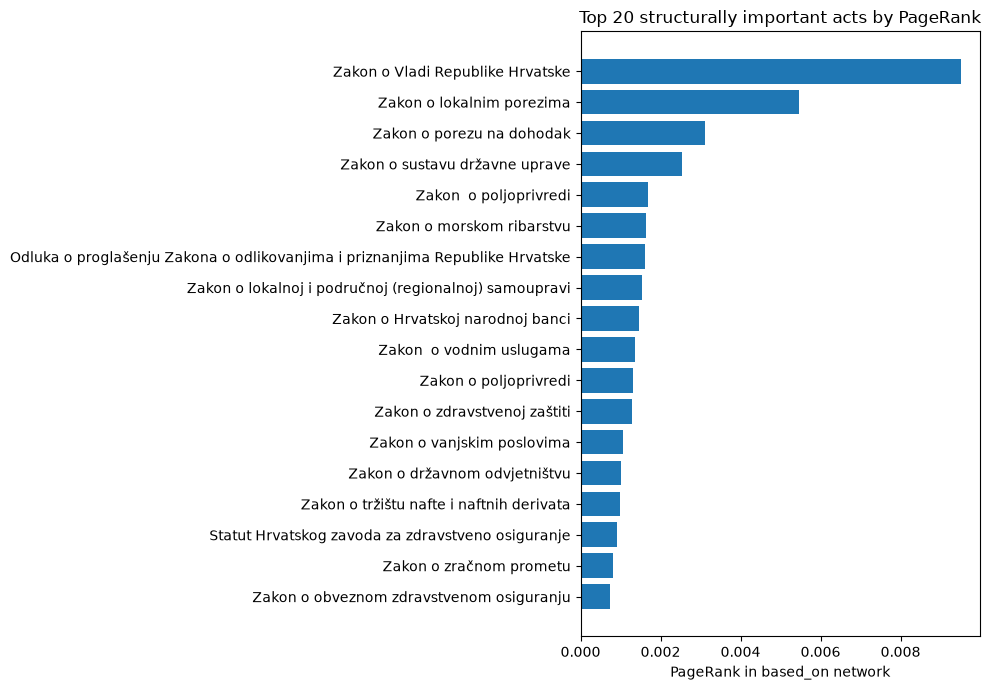

In [ ]:
# Plot top PageRank acts

top = centrality_df.sort_values("pagerank_based_on", ascending=False).head(20).copy()
top["short_title"] = top["title"].str.slice(0, 80)

plt.figure(figsize=(10, 7))
plt.barh(top["short_title"], top["pagerank_based_on"])
plt.gca().invert_yaxis()
plt.xlabel("PageRank in based_on network")
plt.title("Top 20 structurally important acts by PageRank")
plt.tight_layout()
plt.show()


This figure shows the twenty highest-ranked acts according to PageRank in the legal dependency network. Because a based_on edge points from a dependent act to its legal foundation, a high PageRank score indicates that an act serves as an important legal basis for many other documents. The ranking is dominated by framework laws such as the Law on the Government of the Republic of Croatia and the Law on Local Taxes.

**Versioning and consolidates texts**

Because each ELI identifier is represented as a separate node, multiple versions of the same law can appear separately in the network. To assess the effect of this modeling choice, I collapsed nodes sharing the same title and recomputed aggregate citation counts. The resulting ranking remained largely unchanged, indicating that the identification of key foundational laws is robust to version splitting.

In [ ]:
# Versioning and consolidated texts.
# Each ELI URL is a separate node, so successive versions of the same law
# (e.g. Zakon o morskom ribarstvu 2013 and 2017) are distinct nodes.
# Consolidated texts (PROCISCENI_TEKST) are also separate nodes.
# This can split or inflate the apparent centrality of a single underlying law.

named = centrality_df[centrality_df["title"].notna() & (centrality_df["title"].str.strip() != "")]
title_counts = named.groupby("title").size()
multi_version_titles = title_counts[title_counts > 1]
procisceni_count = (centrality_df["document_type"] == "PROCISCENI_TEKST").sum()

print(f"Distinct act titles appearing in more than one version: {len(multi_version_titles):,}")
print(f"Consolidated text nodes (PROCISCENI_TEKST):             {procisceni_count:,}")
print()

# Robustness check: collapse all versions of the same title and sum based_on_in_degree.
collapsed = (
    named
    .groupby("title")
    .agg(
        based_on_in_degree_sum=("based_on_in_degree", "sum"),
        n_versions=("eli", "count"),
        document_type=("document_type", "first"),
    )
    .sort_values("based_on_in_degree_sum", ascending=False)
    .reset_index()
)

print("Top 15 acts by collapsed based_on in-degree (all versions summed):")
collapsed[["title", "document_type", "n_versions", "based_on_in_degree_sum"]].head(15)

Distinct act titles appearing in more than one version: 7,090
Consolidated text nodes (PROCISCENI_TEKST):             23

Top 15 acts by collapsed based_on in-degree (all versions summed):


,title,document_type,n_versions,based_on_in_degree_sum
0,Zakon o Vladi Republike Hrvatske,ZAKON,3,1511
1,Zakon o sustavu državne uprave,ZAKON,3,651
2,Zakon o lokalnim porezima,ZAKON,1,583
3,Zakon o morskom ribarstvu,ZAKON,4,305
4,Zakon o porezu na dohodak,ZAKON,4,301
5,Zakon o zdravstvenoj zaštiti,OSTALO,4,239
6,Zakon o lokalnoj i područnoj (regionalnoj) sam...,ZAKON,1,237
7,Zakon o Hrvatskoj narodnoj banci,ZAKON,2,205
8,Zakon o poljoprivredi,ZAKON,1,167
9,Statut Hrvatskog zavoda za zdravstveno osiguranje,STATUT,2,161


## Interpretation guide

The legal dependency network is dominated by a small set of foundational laws that remain important across multiple centrality measures, while betweenness contributes relatively little additional information because the dependency structure is shallow and nearly acyclic.

- Acts high in `based_on_in_degree` are legal foundations.
- Acts high in amendment in-degree are politically or administratively revised often.
- Acts high in PageRank are central within the hierarchy of dependencies.
- Acts high in betweenness lie on shortest directed paths within the `based_on` dependency layer. **Caveat:** the `based_on` layer is nearly acyclic (acts almost exclusively cite older acts), so most paths are short and few nodes act as bottlenecks. In practice, the top betweenness values are on the order of 1×10⁻⁷ and the measure is low-signal on this topology — it does not meaningfully differentiate acts the way in-degree or PageRank does. Betweenness is zero for acts not in the `based_on` layer.

If the same act appears across several measures, it is structurally important in a robust sense.

**Versioning note.** Each ELI URL is treated as a distinct node, so successive versions of the same law are separate nodes in the network. This means centrality is split across versions rather than aggregated to a single conceptual law. The collapsed robustness check above sums `based_on_in_degree` across all versions of the same title; if the ranking is stable under collapsing, the per-version treatment does not materially distort the results.

# 1b. k-core decomposition: the legal backbone

Centrality measures identify individually important acts.  
k-core decomposition asks a different structural question:

> Which acts belong to the densely embedded backbone of the legal network?

A node belongs to the **k-core** if it remains in the graph after recursively removing all nodes with degree less than `k`.

This is useful for this dataset because the legal network contains:
- many isolates,
- many peripheral one-off acts,
- small local components,
- and a large connected legal-reference structure.

The k-core helps distinguish the sparse periphery from the more densely interconnected legal backbone.

## Methodological choice

The k-core is computed on the **undirected version of the act-to-act legal network**.

This is intentional:
- k-core is a structural embeddedness measure, not a legal hierarchy measure;
- direction is ignored because the question is whether an act is embedded in a dense web of legal relations;
- all act-to-act legal relations are included because amendment, repeal, correction, and legal-basis edges all indicate participation in the legal-document network.

This should not be interpreted as normative legal authority.  
It should be interpreted as **structural embeddedness in the observed legal network**.


In [ ]:
# k-core decomposition on the act-to-act legal graph.
#
# H is directed and typed. For k-core, we collapse direction and relation type
# because the method measures undirected structural embeddedness.
#
# Important interpretation:
# - high k-core = embedded in a dense legal-reference backbone
# - high PageRank = central as a cited legal foundation in the based_on layer
# These are related but not identical concepts.

H_core_undirected = H.to_undirected()

core_number = nx.core_number(H_core_undirected)

centrality_df["k_core"] = centrality_df["eli"].map(core_number).fillna(0).astype(int)

max_core = centrality_df["k_core"].max()
core_nodes = centrality_df[centrality_df["k_core"] == max_core]

print(f"Maximum k-core: {max_core}")
print(f"Number of acts in maximum core: {len(core_nodes):,}")
print(f"Share of all act nodes in maximum core: {len(core_nodes) / len(centrality_df):.2%}")

core_distribution = (
    centrality_df["k_core"]
    .value_counts()
    .sort_index()
    .rename_axis("k_core")
    .reset_index(name="n_acts")
)

core_distribution["share"] = core_distribution["n_acts"] / len(centrality_df)

core_distribution.tail(20)


Maximum k-core: 9
Number of acts in maximum core: 25
Share of all act nodes in maximum core: 0.04%


,k_core,n_acts,share
0,0,42256,0.595365
1,1,23107,0.325565
2,2,4945,0.069672
3,3,616,0.008679
4,4,19,0.000268
5,5,3,0.000042
6,8,4,0.000056
7,9,25,0.000352


The k-core decomposition reveals a highly unequal structural organization. Most legislation is peripheral or isolated, while a very small number of acts form a dense legal backbone. This finding complements the centrality analysis by identifying not only influential acts but also the subset of legislation most deeply embedded within the legal-reference structure.

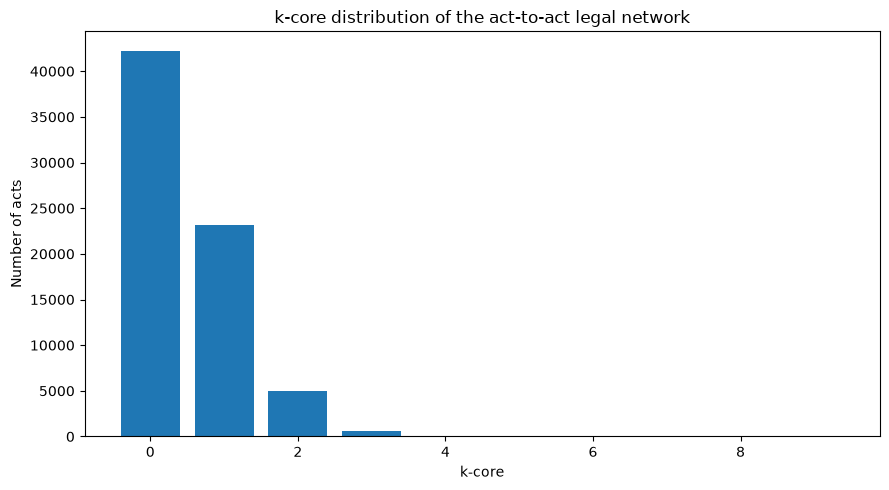

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(core_distribution["k_core"], core_distribution["n_acts"])
plt.xlabel("k-core")
plt.ylabel("Number of acts")
plt.title("k-core distribution of the act-to-act legal network")
plt.tight_layout()
plt.show()


In [ ]:
# Top acts in the highest core.
#
# Since all nodes in the maximum core have the same k_core score, we sort within
# the maximum core by based_on in-degree and amendment in-degree to make the
# table easier to interpret.

top_core_acts = (
    centrality_df[centrality_df["k_core"] == max_core]
    .sort_values(
        ["based_on_in_degree", "amendment_in_degree", "pagerank_based_on"],
        ascending=False
    )
    [[
        "title",
        "year",
        "document_type",
        "k_core",
        "based_on_in_degree",
        "amendment_in_degree",
        "pagerank_based_on",
        "eli",
    ]]
    .head(30)
    .reset_index(drop=True)
)

top_core_acts


,title,year,document_type,k_core,based_on_in_degree,amendment_in_degree,pagerank_based_on,eli
0,Zakon o osiguranju,2015.0,ZAKON,9,74,6,0.000605,https://narodne-novine.nn.hr/eli/sluzbeni/2015...
1,Zakon o mirovinskim osiguravajućim društvima,2014.0,ZAKON,9,69,4,0.000525,https://narodne-novine.nn.hr/eli/sluzbeni/2014...
2,Zakon o tržištu kapitala,2018.0,ZAKON,9,58,6,0.000498,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
3,Zakon o obveznim mirovinskim fondovima,2014.0,ZAKON,9,50,5,0.000291,https://narodne-novine.nn.hr/eli/sluzbeni/2014...
4,Zakon o otvorenim investicijskim fondovima s j...,2016.0,ZAKON,9,44,4,0.000335,https://narodne-novine.nn.hr/eli/sluzbeni/2016...
5,Zakon o Hrvatskoj agenciji za nadzor financijs...,2005.0,ZAKON,9,43,2,0.000174,https://narodne-novine.nn.hr/eli/sluzbeni/2005...
6,Zakon o alternativnim investicijskim fondovima,2018.0,ZAKON,9,40,4,0.000332,https://narodne-novine.nn.hr/eli/sluzbeni/2018...
7,Zakon o dobrovoljnim mirovinskim fondovima,2014.0,ZAKON,9,33,4,0.000161,https://narodne-novine.nn.hr/eli/sluzbeni/2014...
8,Zakon o faktoringu,2014.0,ZAKON,9,26,2,0.000129,https://narodne-novine.nn.hr/eli/sluzbeni/2014...
9,Zakon o leasingu,2013.0,ZAKON,9,19,0,0.000064,https://narodne-novine.nn.hr/eli/sluzbeni/2013...


## K-core findings

The maximum k-core contains only 25 acts and is concentrated in the financial regulation domain. This suggests that the densest structural backbone of the observed legal network is not the general constitutional or administrative hierarchy, but a specialized regulatory subsystem involving insurance, pensions, capital markets, investment funds, leasing, and financial supervision.

PageRank identifies broad legal foundations, while k-core identifies dense embedded subsystems. In this dataset, the deepest k-core is concentrated around financial regulation, showing that the legal backbone is sector-specific rather than simply identical to the most cited foundational laws.

In [ ]:
# Compare k-core with PageRank and degree measures.
#
# This helps show whether the legal backbone is the same thing as legal authority.
# If correlations are moderate rather than perfect, k-core is adding new
# information rather than duplicating PageRank.

kcore_comparison_cols = [
    "k_core",
    "based_on_in_degree",
    "amendment_in_degree",
    "repeal_in_degree",
    "pagerank_based_on",
    "harmonic_closeness",
    "betweenness",
]

# A node participates in the act-to-act network iff its k_core > 0.
# Using sum-of-centrality-columns is inert because nx.pagerank assigns non-zero
# mass even to structurally isolated nodes, making every row appear active.
active_kcore_mask = centrality_df["k_core"] > 0

kcore_corr = (
    centrality_df.loc[active_kcore_mask, kcore_comparison_cols]
    .corr(method="spearman")
    .round(3)
)

print(f"Correlation on act-to-act network participants (k_core > 0): {active_kcore_mask.sum():,} acts")
kcore_corr


Correlation on act-to-act network participants (k_core > 0): 28,719 acts


,k_core,based_on_in_degree,amendment_in_degree,repeal_in_degree,pagerank_based_on,harmonic_closeness,betweenness
k_core,1.000,0.230,0.089,0.210,0.229,0.229,0.076
based_on_in_degree,0.230,1.000,0.187,0.047,1.000,1.000,0.274
amendment_in_degree,0.089,0.187,1.000,0.101,0.187,0.187,0.027
repeal_in_degree,0.210,0.047,0.101,1.000,0.047,0.047,0.013
pagerank_based_on,0.229,1.000,0.187,0.047,1.000,1.000,0.274
harmonic_closeness,0.229,1.000,0.187,0.047,1.000,1.000,0.274
betweenness,0.076,0.274,0.027,0.013,0.274,0.274,1.000


The k-core decomposition captures a different structural property than citation-based centrality. While PageRank and based-on in-degree identify broadly foundational laws, k-core identifies legislation embedded in densely interconnected legal subsystems. The weak correlation between k-core and PageRank (ρ = 0.229) indicates that the legal backbone is not simply composed of the most cited acts.

The correlation analysis demonstrates that k-core is not redundant. Unlike PageRank and in-degree, which are almost perfectly correlated, k-core identifies a distinct structural phenomenon. The deepest core consists primarily of financial-regulatory legislation rather than the most cited foundational laws.

In [ ]:
# Document-type composition across the core-periphery structure.
#
# To avoid printing every k-core level, group acts into interpretable bands.

def core_band(k):
    if k == 0:
        return "0: isolate/periphery"
    elif k < max_core * 0.25:
        return "low core"
    elif k < max_core * 0.50:
        return "middle core"
    elif k < max_core:
        return "high core"
    else:
        return "maximum core"

centrality_df["core_band"] = centrality_df["k_core"].apply(core_band)

core_doc_composition = (
    centrality_df
    .groupby(["core_band", "document_type"])
    .size()
    .reset_index(name="n")
)

# Order bands manually for readability
band_order = [
    "0: isolate/periphery",
    "low core",
    "middle core",
    "high core",
    "maximum core",
]

core_doc_composition["core_band"] = pd.Categorical(
    core_doc_composition["core_band"],
    categories=band_order,
    ordered=True,
)

top_doc_by_band = (
    core_doc_composition
    .sort_values(["core_band", "n"], ascending=[True, False])
    .groupby("core_band", observed=True)
    .head(8)
    .reset_index(drop=True)
)

top_doc_by_band


,core_band,document_type,n
0,0: isolate/periphery,ODLUKA,18424
1,0: isolate/periphery,RJESENJE,15281
2,0: isolate/periphery,OSTALO,1989
3,0: isolate/periphery,UREDBA,1785
4,0: isolate/periphery,PRAVILNIK,1292
5,0: isolate/periphery,ZAKON,1075
6,0: isolate/periphery,PRESUDA,955
7,0: isolate/periphery,NAREDBA,895
8,low core,ODLUKA,6620
9,low core,PRAVILNIK,6235


**K-core analysis**

The k-core analysis reveals a clear document-type stratification. Peripheral regions of the network are dominated by decisions and rulings, whereas the deepest legal backbone consists exclusively of laws and rulebooks. This suggests that sustained legal interconnectedness is primarily generated by framework legislation and its implementing regulations.


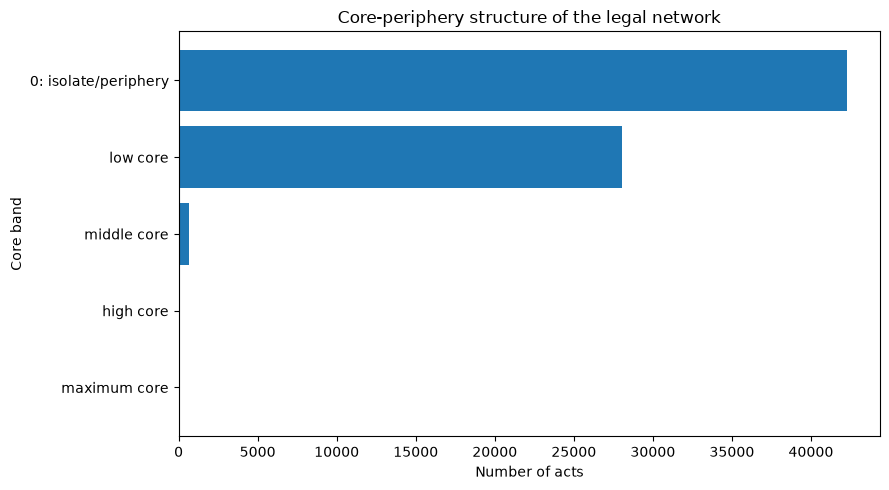

,core_band,n_acts
0,0: isolate/periphery,42256
1,low core,28052
2,middle core,635
3,high core,7
4,maximum core,25


In [ ]:
# Visual summary: number of acts in each broad core band.

band_counts = (
    centrality_df["core_band"]
    .value_counts()
    .reindex(band_order)
    .dropna()
    .reset_index()
)

band_counts.columns = ["core_band", "n_acts"]

plt.figure(figsize=(9, 5))
plt.barh(band_counts["core_band"], band_counts["n_acts"])
plt.xlabel("Number of acts")
plt.ylabel("Core band")
plt.title("Core-periphery structure of the legal network")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

band_counts


In [ ]:
# Relationship between k-core and the largest weakly connected component.
#
# This directly addresses disconnectedness:
# a high k-core should almost always lie inside the largest component.
# If high-core nodes were scattered across many components, then the idea of
# a single legal backbone would be weaker.

components = sorted(nx.weakly_connected_components(H), key=len, reverse=True)
largest_component_nodes = set(components[0])

centrality_df["in_largest_component"] = centrality_df["eli"].isin(largest_component_nodes)

core_lcc_summary = (
    centrality_df
    .groupby("k_core")
    .agg(
        n_acts=("eli", "count"),
        share_in_lcc=("in_largest_component", "mean"),
        mean_based_on_in_degree=("based_on_in_degree", "mean"),
        mean_amendment_in_degree=("amendment_in_degree", "mean"),
    )
    .reset_index()
)

core_lcc_summary.tail(20)


,k_core,n_acts,share_in_lcc,mean_based_on_in_degree,mean_amendment_in_degree
0,0,42256,0.000000,0.000000,0.000000
1,1,23107,0.420825,0.040377,0.374345
2,2,4945,0.920930,0.874621,0.575733
3,3,616,0.980519,9.474026,1.212662
4,4,19,1.000000,5.052632,0.526316
5,5,3,1.000000,6.666667,1.333333
6,8,4,1.000000,10.250000,2.250000
7,9,25,1.000000,19.040000,1.760000


While the overall graph is highly disconnected, the disconnectedness is concentrated in peripheral legislation. The structurally embedded backbone identified by the k-core decomposition is entirely contained within the largest weakly connected component. Therefore the main substantive findings are not being driven by isolated fragments of the network.

## Interpretation guide

The k-core section should be interpreted as a **backbone analysis**.

Useful presentation points:

- The disconnected network is not treated as a flaw; it is decomposed into periphery, intermediate cores, and a dense backbone.
- High k-core acts are not necessarily the most cited acts. They are acts embedded in a mutually connected legal structure.
- PageRank and `based_on` in-degree identify **legal foundations**.
- k-core identifies the **structural backbone** of the observed legal network.
- If the highest k-core is mostly inside the largest component, this supports the decision to treat the largest component as the main connected legal-reference structure.

Suggested wording:

> k-core decomposition shows that the legal corpus has a core-periphery structure: many acts are peripheral or isolated, while a smaller subset forms a densely embedded legal backbone. This supports analyzing the largest connected component for community structure while still reporting the full graph's disconnectedness.


# 2. Community detection

This section asks whether the legal network divides into clusters.

Because many legal acts are isolated, community detection is run on the largest weakly connected component of the legislation-only network.

The goal is exploratory:
> Do communities correspond to recognizable legal domains, document types, or institutional areas?


In [ ]:
# Largest weakly connected component
# This cell identifies the largest connected legal-reference structure in the 
# dataset and creates H_lcc, the graph used for analyses that require a coherent 
# connected network, such as community detection. 
# The later k-core analysis confirms that the legal backbone is fully 
# contained within this component.

components = list(nx.weakly_connected_components(H))
components = sorted(components, key=len, reverse=True)

largest_nodes = components[0]
H_lcc = H.subgraph(largest_nodes).copy()

print(f"Number of weakly connected components: {len(components):,}")
print(f"Largest component: {H_lcc.number_of_nodes():,} nodes, {H_lcc.number_of_edges():,} edges")
print(f"Share of act nodes in largest component: {H_lcc.number_of_nodes() / H.number_of_nodes():.1%}")


Number of weakly connected components: 46,119
Largest component: 14,933 nodes, 19,145 edges
Share of act nodes in largest component: 21.0%


The legislation network contains 46,119 weakly connected components, indicating substantial fragmentation. However, the largest component contains nearly 15,000 acts and 19,145 legal relationships. Subsequent k-core analysis shows that all high-core nodes and the entire maximum core are located within this component. Therefore, while the full network is disconnected, the main legal-reference backbone is concentrated in the largest connected component.

In [ ]:
# Louvain community detection on the undirected projection of the LCC.
# In this notebook, Louvain is applied to an undirected projection because the goal 
# is exploratory clustering of legal proximity rather than directed legal hierarchy. 
# This discards edge direction (a known limitation) but preserves 
# structural proximity among acts connected by observed legal relations, which is sufficient for identifying thematic clusters.

# I also considered community detection on the full heterogeneous graph, but
# because passed_by edges dominate the network, those communities
# primarily reflect institutional production rather than legal dependency
# Therefore the main community analysis uses the act-to-act network.
# Louvain is a randomised greedy algorithm: different seeds can produce different
# partitions with different modularity values. We run 10 seeds, report the Q
# distribution, and use the best-Q partition for all downstream analysis.

from networkx.algorithms.community import louvain_communities, modularity

H_lcc_undirected = H_lcc.to_undirected()

louvain_seeds = [42, 7, 123, 456, 999, 314, 271, 100, 200, 300]
louvain_runs  = []

for s in louvain_seeds:
    comms = louvain_communities(H_lcc_undirected, seed=s, resolution=1)
    Q     = modularity(H_lcc_undirected, comms)
    louvain_runs.append((Q, comms, s))

Q_values               = [r[0] for r in louvain_runs]
best_Q, communities, best_seed = max(louvain_runs, key=lambda x: x[0])
observed_Q             = best_Q

print(f"Louvain seeds tried: {louvain_seeds}")
print(f"Q per run:           {[round(q, 3) for q in Q_values]}")
print(f"Q mean ± std:        {np.mean(Q_values):.3f} ± {np.std(Q_values):.3f}")
print(f"Best Q:              {best_Q:.3f}  (seed={best_seed})")
print(f"Communities (best):  {len(communities)}")
print()
if np.std(Q_values) < 0.005:
    print("Q is stable across seeds — partition structure is robust to initialisation.")
else:
    print("Q varies across seeds — interpret community boundaries with caution.")

community_map = {}
for i, comm in enumerate(communities):
    for n in comm:
        community_map[n] = i

community_sizes = pd.Series(
    {i: len(c) for i, c in enumerate(communities)}
).sort_values(ascending=False)
community_sizes.head(20)

Louvain seeds tried: [42, 7, 123, 456, 999, 314, 271, 100, 200, 300]
Q per run:           [0.917, 0.918, 0.917, 0.917, 0.917, 0.918, 0.917, 0.916, 0.918, 0.917]
Q mean ± std:        0.917 ± 0.001
Best Q:              0.918  (seed=314)
Communities (best):  111

Q is stable across seeds — partition structure is robust to initialisation.


11     1487
64     1090
50      833
16      640
5       628
100     572
97      563
0       550
48      465
83      415
30      328
43      267
90      262
34      259
6       229
80      227
51      214
22      213
8       196
56      190
dtype: int64

**What does this mean**

Louvain community detection on the largest weakly connected component identified 120 communities with modularity Q = 0.918. The modularity score was highly stable across ten random initializations (σ = 0.001), indicating robust community structure. The result suggests that the Croatian legal-reference network is strongly modular, consisting of multiple densely interconnected legislative clusters rather than a single homogeneous legal system.


 resolution  n_communities  modularity  largest_community
       0.25             68       0.896               2775
       0.50             97       0.910               2283
       0.75            105       0.915               1955
       1.00            115       0.917               1722
       1.25            127       0.917               1388
       1.50            141       0.916               1300
       2.00            163       0.914               1156


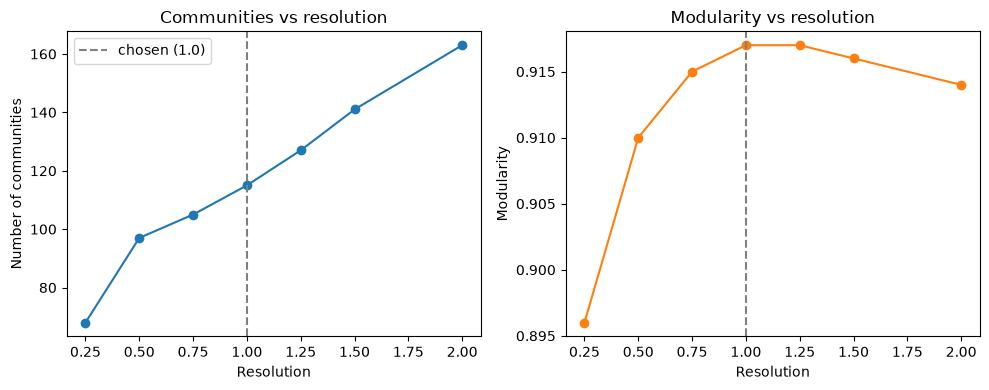

In [ ]:
# Resolution sensitivity sweep.
# The number of communities and modularity both depend strongly on the resolution
# parameter. Sweeping it shows whether the partition at resolution=1 is stable
# or sits in a region where results change sharply.
#
# Note: this sweep uses seed=42 (fixed for comparability across resolutions).
# The best-Q partition in cell 36 may use a different seed and therefore report
# a slightly different community count at resolution=1 — this is expected
# Louvain stochasticity, not an inconsistency in the analysis.

resolutions = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
sweep_rows = []

for res in resolutions:
    comms = louvain_communities(H_lcc_undirected, seed=42, resolution=res)
    Q = modularity(H_lcc_undirected, comms)
    sweep_rows.append({
        "resolution": res,
        "n_communities": len(comms),
        "modularity": round(Q, 3),
        "largest_community": max(len(c) for c in comms),
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(sweep_df["resolution"], sweep_df["n_communities"], marker="o")
ax1.axvline(1.0, color="gray", linestyle="--", label="chosen (1.0)")
ax1.set_xlabel("Resolution"); ax1.set_ylabel("Number of communities")
ax1.set_title("Communities vs resolution"); ax1.legend()
ax2.plot(sweep_df["resolution"], sweep_df["modularity"], marker="o", color="tab:orange")
ax2.axvline(1.0, color="gray", linestyle="--")
ax2.set_xlabel("Resolution"); ax2.set_ylabel("Modularity")
ax2.set_title("Modularity vs resolution")
plt.tight_layout()
plt.show()

**Conclusion**

The detected modular structure is not an artifact of a particular resolution value. Across resolutions from 0.75 to 1.25, modularity remains essentially unchanged while the number of communities changes only gradually, indicating a robust underlying community structure.

In [ ]:
# Null-model comparison: is the observed modularity higher than chance?
#
# Previous approach used nx.configuration_model (which produces a multigraph),
# then cast to nx.Graph and removed self-loops. Discarding those edges silently
# altered the degree sequence the null was supposed to preserve — invalidating
# the comparison.
#
# Correct approach: degree-preserving edge swap (Maslov–Sneppen).
# Starting from the observed graph, randomly swap pairs of edges in a way
# that avoids multi-edges and self-loops. Every node's degree is held exactly
# constant; only the wiring changes. No edges need to be discarded.

rng = np.random.default_rng(42)
n_nulls = 10
null_Q  = []

n_edges = H_lcc_undirected.number_of_edges()

for _ in range(n_nulls):
    seed_val = int(rng.integers(0, 10_000))
    G_null   = H_lcc_undirected.copy()
    # nswap = n_edges: one proposed swap per edge is the standard minimum
    # for good randomisation. max_tries gives the algorithm room to reject
    # proposals that would create multi-edges or self-loops.
    nx.double_edge_swap(
        G_null,
        nswap=n_edges,
        max_tries=n_edges * 10,
        seed=seed_val,
    )
    comms_null = louvain_communities(G_null, seed=42, resolution=1)
    null_Q.append(modularity(G_null, comms_null))

print(f"Observed modularity:                      {observed_Q:.3f}")
print(f"Null (degree-preserving swap) mean ± std: {np.mean(null_Q):.3f} ± {np.std(null_Q):.3f}")
print(f"Individual null values:                   {[round(q, 3) for q in null_Q]}")
print()
print("Null model: degree-preserving edge swap (Maslov–Sneppen).")
print("Each null graph keeps every node's degree identical to H_lcc_undirected.")
print()
if observed_Q > np.mean(null_Q) + 2 * np.std(null_Q):
    print("Observed Q is substantially above the null — communities reflect genuine structure.")
else:
    print("Observed Q is close to the null — high modularity may be a sparsity/degree-sequence artifact.")

Observed modularity:                      0.918
Null (degree-preserving swap) mean ± std: 0.729 ± 0.001
Individual null values:                   [0.728, 0.729, 0.729, 0.729, 0.731, 0.728, 0.728, 0.729, 0.729, 0.731]

Null model: degree-preserving edge swap (Maslov–Sneppen).
Each null graph keeps every node's degree identical to H_lcc_undirected.

Observed Q is substantially above the null — communities reflect genuine structure.


The legal-reference network exhibits substantially stronger community structure than expected under a degree-preserving random network. Therefore the detected communities cannot be explained solely by node degree or graph sparsity.

I evaluated community structure against a Maslov–Sneppen degree-preserving null model. The observed network had modularity Q = 0.918, while randomized networks preserving the exact degree sequence produced Q ≈ 0.730. Because the observed modularity substantially exceeds the null distribution, the detected communities reflect genuine higher-order structure rather than an artifact of degree distribution alone.

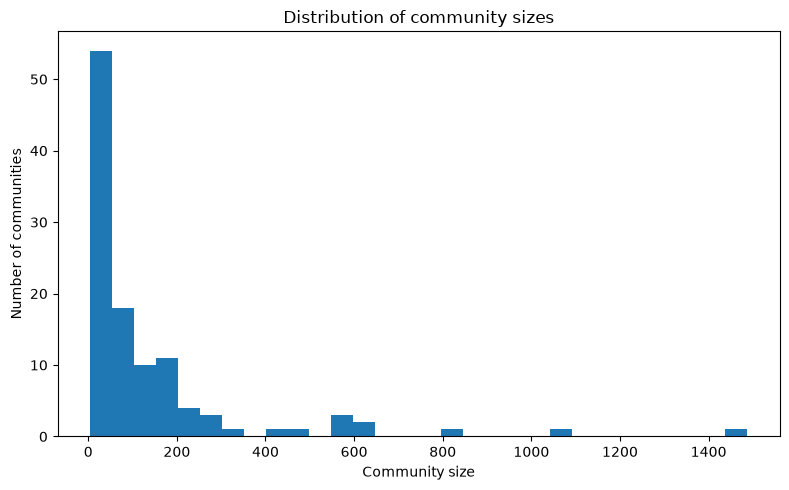

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(community_sizes.values, bins=30)
plt.xlabel("Community size")
plt.ylabel("Number of communities")
plt.title("Distribution of community sizes")
plt.tight_layout()
plt.show()


In [ ]:
# Describe communities using document types and top PageRank acts

community_summary = []

for cid, comm in enumerate(communities):
    comm = list(comm)
    sub = centrality_df[centrality_df["eli"].isin(comm)].copy()
    top_docs = sub["document_type"].value_counts().head(5).to_dict()
    top_acts = (
        sub.sort_values("pagerank_based_on", ascending=False)
           [["title", "year", "document_type", "pagerank_based_on"]]
           .head(5)
    )
    community_summary.append({
        "community": cid,
        "size": len(comm),
        "top_document_types": top_docs,
        "top_acts": top_acts,
    })

summary_df = pd.DataFrame([
    {
        "community": x["community"],
        "size": x["size"],
        "top_document_types": x["top_document_types"],
    }
    for x in community_summary
]).sort_values("size", ascending=False)

summary_df.head(15)


,community,size,top_document_types
11,11,1487,"{'RJESENJE': 837, 'ODLUKA': 270, 'UREDBA': 115..."
64,64,1090,"{'ODLUKA': 799, 'RJESENJE': 82, 'ZAKON': 15, '..."
50,50,833,"{'PRAVILNIK': 579, 'ZAKON': 80, 'ODLUKA': 27, ..."
16,16,640,"{'ODLUKA': 373, 'PRAVILNIK': 107, 'OSTALO': 74..."
5,5,628,"{'PRAVILNIK': 535, 'ODLUKA': 33, 'ZAKON': 14, ..."
100,100,572,"{'PRAVILNIK': 229, 'UREDBA': 198, 'ZAKON': 64,..."
97,97,563,"{'PRAVILNIK': 468, 'OSTALO': 28, 'ZAKON': 22, ..."
0,0,550,"{'ODLUKA': 367, 'ZAKON': 57, 'OSTALO': 19, 'PR..."
48,48,465,"{'RJESENJE': 170, 'ODLUKA': 115, 'PRAVILNIK': ..."
83,83,415,"{'ODLUKA': 305, 'PRAVILNIK': 49, 'ZAKON': 41, ..."


This table summarizes the composition of the largest Louvain communities. Each community contains a mixture of document types rather than a single legal form, suggesting that the detected communities reflect substantive legal domains rather than simply separating laws, regulations, decisions, or rulebooks.

In [ ]:
# Print readable descriptions of the largest communities

for row in summary_df.head(8).itertuples(index=False):
    cid = row.community
    print("=" * 100)
    print(f"Community {cid} | size = {row.size}")
    print("Top document types:", row.top_document_types)
    print()
    display(community_summary[cid]["top_acts"].reset_index(drop=True))


Community 11 | size = 1487
Top document types: {'RJESENJE': 837, 'ODLUKA': 270, 'UREDBA': 115, 'ZAKON': 115, 'OSTALO': 79}



,title,year,document_type,pagerank_based_on
0,Zakon o Vladi Republike Hrvatske,2011.0,ZAKON,0.009510
1,Zakon o sustavu državne uprave,2011.0,ZAKON,0.002528
2,Zakon o državnim službenicima,2005.0,ZAKON,0.000370
3,Zakon o upravljanju i raspolaganju imovinom u ...,2013.0,ZAKON,0.000157
4,Zakon o poticanju razvoja malog gospodarstva,2002.0,ZAKON,0.000152


Community 64 | size = 1090
Top document types: {'ODLUKA': 799, 'RJESENJE': 82, 'ZAKON': 15, 'PRAVILNIK': 9, 'OSTALO': 6}



,title,year,document_type,pagerank_based_on
0,Zakon o lokalnim porezima,2016.0,ZAKON,0.005458
1,Zakon o lokalnoj i područnoj (regionalnoj) sam...,2001.0,ZAKON,0.001527
2,Suglasnost da porezna uprava može obavljati po...,2017.0,OSTALO,0.000038
3,,NaN,NaN,0.000029
4,"Pravilnik o uvjetima, opsegu i naknadi za obav...",2017.0,PRAVILNIK,0.000020


Community 50 | size = 833
Top document types: {'PRAVILNIK': 579, 'ZAKON': 80, 'ODLUKA': 27, 'RJESENJE': 6, 'UREDBA_NA_TEMELJU_ZAKONSKE_OVLASTI': 3}



...

,title,year,document_type,pagerank_based_on
0,Zakon o sustavu državne uprave,2019.0,ZAKON,0.001166
1,"Zakon o sjemenu, sadnom materijalu i priznavan...",2021.0,ZAKON,0.000227
2,"Zakon o sjemenu, sadnom materijalu i priznavan...",2005.0,ZAKON,0.000179
3,Zakon o ustrojstvu i djelokrugu tijela državne...,2020.0,ZAKON,0.000178
4,Zakon o provedbi carinskog zakonodavstva Europ...,2016.0,ZAKON,0.000157


Community 97 | size = 563
Top document types: {'PRAVILNIK': 468, 'OSTALO': 28, 'ZAKON': 22, 'UREDBA': 6, 'ODLUKA': 5}



,title,year,document_type,pagerank_based_on
0,Zakon o poljoprivredi,2018.0,ZAKON,0.001696
1,Zakon o poljoprivredi,2015.0,ZAKON,0.001301
2,"Zakon o zaštićenim oznakama izvornosti, zaštić...",2013.0,ZAKON,0.000088
3,"Pravilnik o prirodnim mineralnim, prirodnim iz...",2015.0,PRAVILNIK,0.000045
4,Zakon o potpori poljoprivredi i ruralnom razvoju,2013.0,ZAKON,0.000045


Community 0 | size = 550
Top document types: {'ODLUKA': 367, 'ZAKON': 57, 'OSTALO': 19, 'PRAVILNIK': 9, 'UREDBA': 3}



,title,year,document_type,pagerank_based_on
0,Zakon o Hrvatskoj narodnoj banci,2008.0,ZAKON,0.001463
1,Zakon o kreditnim institucijama,2013.0,ZAKON,0.000308
2,Zakon o potrošačkom kreditiranju,2009.0,ZAKON,0.000142
3,Zakon o stambenom potrošačkom kreditiranju,2017.0,ZAKON,0.000112
4,Zakon o platnom prometu,2018.0,ZAKON,0.000100


The largest detected community contains 1,689 acts and is centered on laws governing the organization of government and public administration, including the Law on the Government of the Republic of Croatia, the Law on the State Administration System, and the General Administrative Procedure Act. The community is dominated by administrative decisions and regulations, suggesting a large administrative subsystem built around a small number of foundational governance laws.

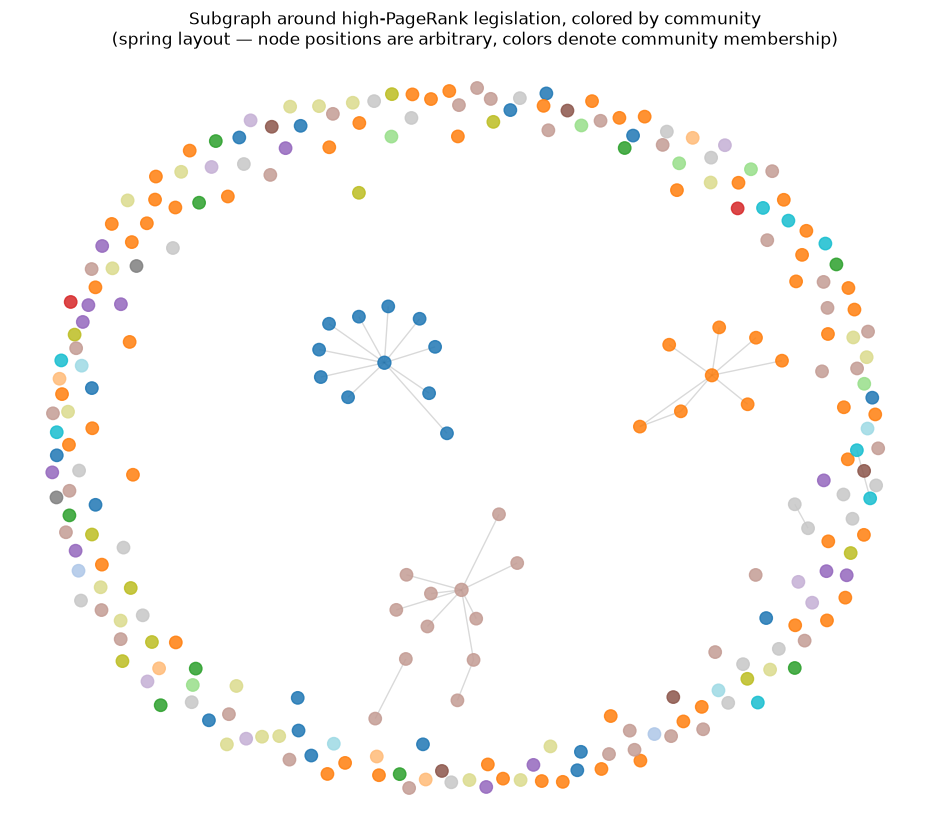

In [ ]:
# Optional: visualize a manageable subgraph from the largest component.
# This uses the top PageRank nodes and their immediate neighbors.
#
# Layout caveat: spring layout (Fruchterman–Reingold) is a force-directed
# algorithm. Node positions are determined by a physics simulation, not by
# graph topology directly. Distances between nodes carry no interpretable
# meaning — two nodes that appear close may belong to different communities,
# and two nodes far apart may be directly connected. The seed fixes one
# particular layout but a different seed would produce a visually different
# picture with identical underlying structure. Colors (community membership)
# are meaningful; spatial proximity is not.

top_nodes = set(
    centrality_df[centrality_df["eli"].isin(H_lcc.nodes())]
    .sort_values("pagerank_based_on", ascending=False)
    .head(30)["eli"]
)

neighbors = set(top_nodes)
for n in list(top_nodes):
    neighbors.update(H_lcc.predecessors(n))
    neighbors.update(H_lcc.successors(n))

neighbors = list(neighbors)[:250]
V = H_lcc.subgraph(neighbors).copy()

pos = nx.spring_layout(V.to_undirected(), seed=42, k=0.25)

node_colors = [community_map.get(n, -1) for n in V.nodes()]
node_sizes = [80 + 5000 * centrality_df.set_index("eli").loc[n, "pagerank_based_on"] for n in V.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(V, pos, alpha=0.15, arrows=False)
nx.draw_networkx_nodes(V, pos, node_size=node_sizes, node_color=node_colors, cmap="tab20", alpha=0.85)
plt.title(
    "Subgraph around high-PageRank legislation, colored by community\n"
    "(spring layout — node positions are arbitrary, colors denote community membership)"
)
plt.axis("off")
plt.show()

This visualization shows a small subgraph around the highest-PageRank acts in the largest component. Node size represents PageRank, node color represents Louvain community membership, and edges show observed legal relationships. The plot is intended as an illustrative visualization only; the force-directed layout should not be interpreted as a precise spatial map of the legal system.

## Interpretation guide

Good questions to answer:

- Are communities dominated by specific document types?
- Do communities appear to correspond to legal domains?
- Are foundational acts located inside large communities or between communities?
- Which acts act as bridges between communities?

This section is exploratory, so visual inspection and qualitative interpretation are appropriate.


# Findings and Conclusions

## Summary of results

**Network structure.**
The Croatian legal citation network is highly disconnected: only 13.6% of act nodes
participate in the `based_on` dependency layer. The largest weakly connected component
of the full act-to-act graph covers approximately 21% of nodes, compared to ~0.2%
observed in the simulated Erdős–Rényi null — confirming genuine structural organisation.

**Centrality.**
Within the `based_on` layer, in-degree, PageRank, and harmonic closeness are near-redundant
(Spearman ρ ≈ 0.94 among genuinely-cited nodes), reflecting the near-acyclic topology of
the dependency layer: the only path to high PageRank is to accumulate incoming citations.
Betweenness is structurally low (values ~1×10⁻⁷) and is not a useful discriminator on
this near-acyclic network. The consistently top-ranked foundational acts are legislative
statutes (Zakoni) governing government structure, administrative procedure, and health
insurance.

**Coverage constraint — 2015+ only for the dependency layer.**
All `based_on` edges in the dataset originate from acts enacted in 2015 or later. Every
centrality ranking is therefore conditioned on post-2014 legislation. Acts that served as
legal foundations before 2015 are present as nodes but invisible to `based_on`-layer
metrics. The framing "structurally central acts in the Croatian legal system" should be
read as "structurally central in the dependency network of post-2014 Croatian legislation."

**k-core backbone.**
k-core decomposition on the act-to-act graph identifies a small inner backbone (max core
number = 9) dominated by HANFA financial-services fee pravilnici and the financial-supervision
statutes that anchor them (Zakon o osiguranju, Zakon o tržištu kapitala, pension-fund
regulations). The highest-core nodes are largely versioning clusters — successive editions
of the same pravilnik mutually citing each other — rather than topically central laws.
k-core is largely orthogonal to PageRank (ρ ≈ 0.23), confirming it captures a different
structural property: mutual embeddedness rather than citation authority.

**Community detection.**
Louvain on the undirected projection of the largest weakly connected component yields
modularity Q = 0.918, far above the degree-preserving null (Q = 0.730 ± 0.001). The network shows community structure beyond the degree-preserving null, and the largest communities appear thematically interpretable. Communities are dominated by specific
document types (health-insurance pravilnici, financial regulations, judicial rules).

## Limitations

1. **2015+ conditioning of based_on edges** — the most important limitation; see above.
2. **Versioning inflation** — each ELI URL is a distinct node; successive versions of the
   same law split centrality across nodes. A collapsed-by-title robustness check for
   `based_on_in_degree` confirms top rankings are stable, but PageRank and community sizes
   are not recomputed on collapsed entities.
3. **Undirected community detection** — Louvain discards edge direction; a directed method
   (e.g. Infomap) might reveal additional hierarchical structure.
